In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 0. Cargar Datos

## 0.1 Ventas

In [2]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_85748/3181763947.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 9638476


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1145633,CB,32,SUR 3,PUNTA ARENAS,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,...,1153.80,-5.876235,0.0,-5.876235,base_forzado,NaN,False,True,46152.0,2712.0
1,43790,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.0,...,8145.00,-2.983425,-3.0,0.016575,base,2352.0,True,False,32580.0,972.0
2,1227049,HR,37,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.4,...,1034.36,0.000242,0.0,0.000242,ninguno,NaN,False,False,82748.8,-0.2
3,1174760,CB,32,NaN,NaN,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,...,517.10,-12.476633,-12.5,0.023367,base,2372.0,True,False,12410.4,1548.4
4,1015869,HR,55,SANTIAGO,SANTIAGO HORECA PAP,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.8,...,2585.60,-3.001238,0.0,-3.001238,base_forzado,NaN,False,True,15513.6,465.6


In [3]:
ventas.columns

Index(['cod_cliente', 'cod_canal_comercial', 'cod_consolidado', 'zona',
       'distrito', 'fecha_factura', 'cod_sku', 'nombre_sku', 'monto_real',
       'kilo_real', 'precio_real', 'precio_lista', 'dscto_base',
       'dscto_volumen', 'dscto_binario', 'carta_impacto', 'id_descuento_base',
       'ids_descuento_volumen', 'id_descuento_binario',
       'id_descuento_carta_impacto', 'año_factura', 'mes_factura',
       'kg_por_unidad', 'peso_variable', 'cantidad_unidades',
       'cantidad_unidades_entera', 'inconsistencia', 'precio_por_unidad',
       'precio_lista_por_unidad', 'descuento_pct_observado',
       'descuento_pct_matcheado', 'diferencia_descuento_pct',
       'descuento_aplicado', 'id_descuento_aplicado', 'calza_con_descuento',
       'gap', 'monto_a_precio_lista', 'costo_descuento'],
      dtype='str')

In [4]:
# ventas["Nombre Consolidado"].unique()
# ## Filtrar solo los canales relevantes
# canales_relevantes = [
#     "COBERTURA",
#     "VOLUMEN COBERTURA",
#     "MAYORISTAS CADENAS",
#     "MAYORISTA B VOLUMEN",
#     "OTROS MAYORISTAS",
#     "HORECA VOLUMEN",
#     "OTROS HORECA",
# ]
# ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
# print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
# ventas.head()

## 0.2 Descuentos consolidados

In [5]:
path_descuentos = "datos/Descuentos históricos/consolidado_descuentos.csv"
descuentos = pd.read_csv(path_descuentos)
print("Descuentos - Filas:", descuentos.shape[0])
descuentos.head()

Descuentos - Filas: 76509


,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
0,1,base,1006,CB,54.0,NaN,2026-03-02,2026-03-18,0.0,338
1,2,base,1006,CB,54.0,NaN,2026-03-19,9999-12-31,0.0,339
2,3,base,1006,HR,55.0,NaN,2026-03-02,2026-03-18,0.0,1118
3,4,base,1006,HR,55.0,NaN,2026-03-19,2026-03-29,0.0,1119
4,5,base,1006,HR,56.0,NaN,2023-11-01,2024-06-09,-24.8,1656


In [6]:
descuentos[descuentos["cod_consolidado"].isna()]

,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
44,45,base,1020,CB,NaN,NaN,2024-02-05,2024-02-29,-10.0,3643
4898,4899,carta_impacto,1006,NaN,NaN,1002215.0,2026-04-01,2026-04-10,2878.0,3422
4899,4900,carta_impacto,1006,NaN,NaN,1002667.0,2026-04-06,2026-04-10,2878.0,3629
4900,4901,carta_impacto,1006,NaN,NaN,1008117.0,2026-04-07,2026-04-10,2878.0,3732
4901,4902,carta_impacto,1006,NaN,NaN,1039197.0,2026-04-06,2026-04-10,2878.0,3975
...,...,...,...,...,...,...,...,...,...,...
74335,74336,carta_impacto,970,NaN,NaN,92024.0,2026-04-01,2026-04-30,3746.0,20539
75634,75635,volumen,6770,CB,NaN,NaN,2024-04-15,2024-04-25,-21.2,2179
75696,75697,volumen,6771,CB,NaN,NaN,2024-04-15,2024-04-25,-26.8,2180
75843,75844,volumen,689,CB,NaN,NaN,2024-05-12,2024-05-25,-20.0,2178


## 0.3 Costos por SKU

In [7]:
# Un Excel con varias hojas, una por mes, mismas columnas en todas las hojas
# Concatenar todas las hojas en un solo DataFrame con una columna adicional que indique el mes
path_costos = "datos/Consolidado ABC SKU (oct25'-mar26') FINAL.xlsx"
lista_dfs_costos = []
xls = pd.ExcelFile(path_costos, engine="openpyxl")
for sheet_name in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet_name, engine="openpyxl")
    df["Mes"] = sheet_name  # Agregar columna con el nombre de la hoja (mes)
    lista_dfs_costos.append(df)
costos = pd.concat(lista_dfs_costos, ignore_index=True)
print("Costos - Filas:", costos.shape[0])
costos.head()

Costos - Filas: 1362


,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,...,Energía por kilo,Distribución Fijo por kilo,T Producción por kilo,Gastos DM Canales por kilo,Gastos DM Marketing por kilo,Reponer por kilo,Gastos. Zonales Directos por kilo,O. G. Fijos Indirectos por kilo,Otros Distribución Variable por kilo,Mes
0,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,...,109.616023,51.243956,536.821480,15.667047,69.781019,107.213380,165.224788,356.538820,11.496824,Mar 26
1,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,...,109.616023,51.243956,651.298434,11.683227,70.917961,46.616111,174.134955,361.737830,1.065923,Mar 26
2,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,...,113.161033,51.243956,618.843430,10.371729,69.481203,84.973946,173.792703,355.245462,7.533394,Mar 26
3,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,...,100.040929,51.243956,256.383338,18.882393,79.456343,78.698590,153.891363,402.053980,30.895221,Mar 26
4,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,...,62.693270,51.243956,543.850298,9.115506,48.949864,76.885585,100.209147,259.732670,11.442677,Mar 26


In [8]:
costos.columns

Index(['SKU', ' Kilos Finales', 'Facturación', 'Aporte', 'Costo',
       'Frío Externo', 'Energía', 'Distribución Fijo', 'T Producción',
       'Gastos DM Canales', 'Gastos DM Marketing', 'Reponer',
       'Gastos. Zonales Directos', 'O. G. Fijos Indirectos',
       'Otros Distribución Variable', 'Aporte por kilo', 'Costo por kilo',
       'Frío Externo por kilo', 'Energía por kilo',
       'Distribución Fijo por kilo', 'T Producción por kilo',
       'Gastos DM Canales por kilo', 'Gastos DM Marketing por kilo',
       'Reponer por kilo', 'Gastos. Zonales Directos por kilo',
       'O. G. Fijos Indirectos por kilo',
       'Otros Distribución Variable por kilo', 'Mes'],
      dtype='str')

In [9]:
cols_costos = ["Mes", "SKU", ' Kilos Finales', 'Facturación', 'Aporte', 'Costo',
       'Frío Externo', 'Energía', 'Distribución Fijo', 'T Producción',
       'Gastos DM Canales', 'Gastos DM Marketing', 'Reponer',
       'Gastos. Zonales Directos', 'O. G. Fijos Indirectos',
       'Otros Distribución Variable']

costos = costos[cols_costos]
costos.head()

,Mes,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,Mar 26,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,4.050366e+06,6.223088e+06,9.590299e+06,2.069492e+07,6.673211e+05
1,Mar 26,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,2.376188e+05,1.561926e+05,5.834592e+05,1.212044e+06,3.571497e+03
2,Mar 26,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,1.965619e+06,2.403908e+06,4.916585e+06,1.004987e+07,2.131193e+05
3,Mar 26,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,1.043556e+06,1.033604e+06,2.021163e+06,5.280456e+06,4.057686e+05
4,Mar 26,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,8.715810e+06,1.368993e+07,1.784283e+07,4.624692e+07,2.037436e+06


In [10]:
costos_totales = costos.groupby(["SKU"]).sum().reset_index()
costos_totales.head()

,SKU,Mes,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,20,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,335586.218,1662597580,153623897.0,6.106304e+08,7.001417e+06,4.006351e+07,1.867814e+07,1.710162e+08,6.286412e+06,2.557901e+07,3.301842e+07,5.643622e+07,1.059107e+08,3.132913e+06
1,27,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,19992.314,96892820,5081558.0,3.159423e+07,4.193767e+05,2.394141e+06,1.112293e+06,1.034808e+07,1.377657e+05,1.474946e+06,8.965587e+05,3.313494e+06,6.182961e+06,3.760482e+04
2,30,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,166105.952,823931212,66366773.0,3.727935e+08,3.463517e+06,2.051210e+07,9.254694e+06,9.408060e+07,3.468700e+06,1.265933e+07,1.274087e+07,3.103956e+07,5.252660e+07,1.192458e+06
3,102,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,76809.925,431581113,33333712.0,1.736206e+08,1.609275e+06,8.061725e+06,4.282384e+06,1.821598e+07,2.161787e+06,6.481077e+06,5.942076e+06,1.108287e+07,2.718273e+07,4.919939e+06
4,151,Dic 25Nov 25Oct 25,4611.500,16473437,110102.0,6.366029e+06,5.175683e+04,2.510712e+05,2.476763e+05,2.694126e+06,2.367651e+04,1.942270e+05,4.545280e+04,4.993600e+05,1.016952e+06,1.800514e+04


In [11]:
costos_totales["Margen Producción"] = (
    costos_totales["Facturación"]
    - costos_totales["Costo"]
    - costos_totales["Distribución Fijo"]
    - costos_totales["Frío Externo"]
)

In [12]:
costos_totales["Margen por Kilo"] = costos_totales["Margen Producción"] / costos_totales[" Kilos Finales"]

# 1. Cruzar Datos y Filtrar

In [13]:
# Filtramos descuentos para quedarnos solo con aquellos no nulos
descuentos = descuentos[descuentos["monto_descuento"] < 0]

# Que no son cartas de impacto
descuentos = descuentos[descuentos["tipo_descuento"] != "carta_impacto"]

# Que son de un cod_consolidado presente en ventas
cod_consolidado_ventas = ventas["cod_consolidado"].unique()
descuentos = descuentos[descuentos["cod_consolidado"].isin(cod_consolidado_ventas)]

# Que son de un periodo entre 2025 y 2026
descuentos["fecha_inicio"] = pd.to_datetime(descuentos["fecha_inicio"])
descuentos["fecha_fin"] = pd.to_datetime(descuentos["fecha_fin"])
descuentos = descuentos[
    (descuentos["fecha_inicio"].dt.year >= 2025)
]

print("Descuentos después de filtrar - Filas:", descuentos.shape[0])

Descuentos después de filtrar - Filas: 3636


# 2. Análisis Exploratorio

In [14]:
# Armar grupos de descuentos por SKU, canal. Si dos descuentos comparten rango de fechas, SKU y canal les asignamos el mismo valor en la columna "grupo_descuento"
# descuentos["grupo_descuento"] = (descuentos.groupby(["cod_sku", "cod_canal", "cod_consolidado"])["fecha_inicio"].rank(method="dense") + descuentos.groupby(["cod_sku", "cod_canal", "cod_consolidado"])["fecha_fin"].rank(method="dense")) // 2
# descuentos.head()

In [15]:
# Verificación de que no hay descuentos con el mismo grupo_descuento pero diferente SKU, canal o cod_consolidado
# descuentos.groupby(["cod_sku", "cod_canal", "fecha_inicio", "fecha_fin"]).size().reset_index(name="count")

In [16]:
# Fijamos un id_descuento
ID_DESCUENTO_EJEMPLO = 70 #descuentos["id_descuento"].values[1]

# Buscamos la llave primaria del descuento
SKU_EJEMPLO = descuentos[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO]["cod_sku"].values[0]
COD_CANAL_EJEMPLO = descuentos[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO]["cod_canal"].values[0]
COD_CONSOLIDADO_EJEMPLO = int(descuentos[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO]["cod_consolidado"].values[0])

In [17]:
print("Ejemplo de descuento:")
print("ID Descuento:", ID_DESCUENTO_EJEMPLO)
print("SKU:", SKU_EJEMPLO)
print("Código Canal:", COD_CANAL_EJEMPLO)
print("Código Consolidado:", COD_CONSOLIDADO_EJEMPLO)
fechas_desde = pd.to_datetime(descuentos.loc[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO, "fecha_inicio"].iloc[0])
fechas_hasta = pd.to_datetime(descuentos.loc[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO, "fecha_fin"].iloc[0])
print("Desde:", fechas_desde.strftime("%Y-%m-%d"))
print("Hasta:", fechas_hasta.strftime("%Y-%m-%d"))
dias_descuento = (pd.to_datetime(fechas_hasta) - pd.to_datetime(fechas_desde)).days + 1
print("Duración del descuento (días):", dias_descuento)
print("Monto del descuento:", descuentos[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO]["monto_descuento"].values[0])

Ejemplo de descuento:
ID Descuento: 70
SKU: 1020
Código Canal: MY
Código Consolidado: 38
Desde: 2025-01-01
Hasta: 2025-01-31
Duración del descuento (días): 31
Monto del descuento: -3.0


## 2.1 Calcular baseline de contribución

In [18]:
n_ventas_sku = ventas[ventas["cod_sku"] == SKU_EJEMPLO].shape[0]
n_ventas_sku_canal = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO) & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)
].shape[0]
n_ventas_sku_canal_consolidado = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO)    & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)    & (ventas["cod_consolidado"] == COD_CONSOLIDADO_EJEMPLO)
].shape[0]
print(f"Número de ventas para SKU {SKU_EJEMPLO}: {n_ventas_sku}")
print(f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO}: {n_ventas_sku_canal}")
print(f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO} y consolidado {COD_CONSOLIDADO_EJEMPLO}: {n_ventas_sku_canal_consolidado}")

# Determinar periodo sin ningún descuento aplicado
ventas_sin_descuento = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO)
    & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)
    & (ventas["cod_consolidado"] == COD_CONSOLIDADO_EJEMPLO)
    & (ventas["descuento_aplicado"] == "ninguno")  # Solo filas sin descuento
]

# Calcular cantidad de días sin descuento
ventas_sin_descuento["fecha_factura"] = pd.to_datetime(ventas_sin_descuento["fecha_factura"])
dias_sin_descuento = len(ventas_sin_descuento["fecha_factura"].unique())

# Calcular demanda por día sin descuento
demanda_total_sin_descuento = ventas_sin_descuento["kilo_real"].sum()
demanda_diaria_sin_descuento = demanda_total_sin_descuento / dias_sin_descuento

# Calcular rentabilidad por día en el periodo sin descuento
# Para esto, necesitamos el margen por kilo en el periodo sin descuento
margen_por_kilo = costos_totales[costos_totales["SKU"] == SKU_EJEMPLO]["Margen por Kilo"].values[0]
margen_diario_sin_descuento = demanda_diaria_sin_descuento * margen_por_kilo

# Print de todos los números clave
print(f"Periodo sin descuento: {dias_sin_descuento} días")
print(f"Demanda total sin descuento: {demanda_total_sin_descuento} kg")
print(f"Demanda diaria sin descuento: {demanda_diaria_sin_descuento} kg")
print(f"Margen por kilo: {margen_por_kilo}")
print(f"Rentabilidad diaria sin descuento: ${margen_diario_sin_descuento:.2f}")

Número de ventas para SKU 1020: 494579
Número de ventas para SKU 1020 en canal MY: 11542
Número de ventas para SKU 1020 en canal MY y consolidado 38: 3837
Periodo sin descuento: 36 días
Demanda total sin descuento: 800.0 kg
Demanda diaria sin descuento: 22.22222222222222 kg
Margen por kilo: 1735.4458660329185
Rentabilidad diaria sin descuento: $38565.46


## 2.2 Calcular contribución durante el descuento

In [19]:
# Determinar periodo del descuento aplicado
ventas_con_descuento = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO)
    & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)
    & (ventas["cod_consolidado"] == COD_CONSOLIDADO_EJEMPLO)
    & (ventas["id_descuento_aplicado"] == ID_DESCUENTO_EJEMPLO)  # Solo filas del descuento
]

# Calcular cantidad de días con descuento
fecha_inicio_descuento = pd.to_datetime(descuentos.loc[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO, "fecha_inicio"].iloc[0])
fecha_fin_descuento = pd.to_datetime(descuentos.loc[descuentos["id_descuento"] == ID_DESCUENTO_EJEMPLO, "fecha_fin"].iloc[0])

dias_con_descuento = (pd.to_datetime(fecha_fin_descuento) - pd.to_datetime(fecha_inicio_descuento)).days + 1

# Calcular demanda por día con descuento
demanda_total_con_descuento = ventas_con_descuento["kilo_real"].sum()
demanda_diaria_con_descuento = demanda_total_con_descuento / dias_con_descuento

# Calcular rentabilidad por día en el periodo con descuento
margen_diario_con_descuento = demanda_diaria_con_descuento * margen_por_kilo

# Print de todos los números clave
print(f"\nPeriodo con descuento: {dias_con_descuento} días")
print(f"Demanda total con descuento: {demanda_total_con_descuento:.2f} kg")
print(f"Demanda diaria con descuento: {demanda_diaria_con_descuento:.2f} kg")
print(f"Rentabilidad diaria con descuento: ${margen_diario_con_descuento:.2f}")


Periodo con descuento: 31 días
Demanda total con descuento: 6095.00 kg
Demanda diaria con descuento: 196.61 kg
Rentabilidad diaria con descuento: $341211.05


## 2.3 Calcular ROP

In [20]:
# Comparamos demanda y rentabilidad diaria con y sin descuento
incremento_demanda_diaria = demanda_diaria_con_descuento - demanda_diaria_sin_descuento
incremento_rentabilidad_diaria = margen_diario_con_descuento - margen_diario_sin_descuento

print(f"\nIncremento en demanda diaria debido al descuento: {incremento_demanda_diaria:.2f} kg")
print(f"Incremento en rentabilidad diaria debido al descuento: ${incremento_rentabilidad_diaria:.2f}")


Incremento en demanda diaria debido al descuento: 174.39 kg
Incremento en rentabilidad diaria debido al descuento: $302645.59


In [21]:
demanda_baseline = demanda_diaria_sin_descuento * dias_con_descuento
incremento_demanda_total = demanda_total_con_descuento - demanda_baseline
incremento_rentabilidad_total = (margen_diario_con_descuento - margen_diario_sin_descuento) * dias_con_descuento

print(f"\nIncremento total en demanda debido al descuento: {incremento_demanda_total:.2f} kg")
print(f"Incremento total en rentabilidad debido al descuento: ${incremento_rentabilidad_total:.2f}")


Incremento total en demanda debido al descuento: 5406.11 kg
Incremento total en rentabilidad debido al descuento: $9382013.18


In [22]:
costo_promocion = ventas_con_descuento["costo_descuento"].sum()
rop = incremento_rentabilidad_total / costo_promocion if costo_promocion != 0 else np.inf
print(f"Return on Promotion (ROP): {rop:.2f}")

Return on Promotion (ROP): 18.11


# 3 Análisis completo

In [23]:
# Creamos una función para automatizar este análisis para cualquier descuento dado su id_descuento
baseline_cache = {}

def _normalizar_clave_baseline(valor):
    return None if pd.isna(valor) else valor

from pathlib import Path
import pickle

cache_path = Path("baseline_cache.pkl")
if cache_path.exists():
    with cache_path.open("rb") as f:
        baseline_cache_raw = pickle.load(f)

    baseline_cache = {}
    for key, value in baseline_cache_raw.items():
        if isinstance(key, tuple) and len(key) == 5:
            _, _, sku, canal, consolidado = key
            baseline_cache[(
                id(ventas),
                id(costos_totales),
                sku,
                canal,
                _normalizar_clave_baseline(consolidado),
            )] = value
        else:
            baseline_cache[key] = value

    print(f"Cache cargado desde {cache_path}: {len(baseline_cache)} entradas")
else:
    baseline_cache = {}
    print(f"No se encontró {cache_path}. Se usará un cache vacío.")

def analizar_descuento(id_descuento):
    # Buscar la información del descuento
    descuento_base = descuentos[descuentos["id_descuento"] == id_descuento]
    if descuento_base.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    descuento = descuento_base.iloc[0]
    sku = descuento["cod_sku"]
    canal = descuento["cod_canal"]
    consolidado = descuento["cod_consolidado"]
    fecha_inicio = pd.to_datetime(descuento["fecha_inicio"])
    fecha_fin = pd.to_datetime(descuento["fecha_fin"])

    baseline_key = (id(ventas), id(costos_totales), sku, canal, _normalizar_clave_baseline(consolidado))

    if baseline_key not in baseline_cache:
        # Filtrar ventas llave
        # Caso con todas las llaves
        if pd.notna(consolidado) and str(consolidado).strip() != "":
            ventas_llave = ventas[
                (ventas["cod_sku"] == sku)
                & (ventas["cod_canal_comercial"] == canal)
                & (ventas["cod_consolidado"] == consolidado)
            ].copy()
        # Caso en que consolidado es nan o vacío -> omitimos el filtro de cod_consolidado
        else:
            ventas_llave = ventas[
                (ventas["cod_sku"] == sku)
                & (ventas["cod_canal_comercial"] == canal)
            ].copy()

        # Filtrar ventas sin descuento
        ventas_sin_descuento = ventas_llave[
            (ventas_llave["descuento_aplicado"] == "ninguno")
        ]
        # Revisamos la cantidad de ventas sin descuento, si no hay entonces usamos como muestra aquellas que fueron a precio máximo
        if ventas_sin_descuento.shape[0] == 0:
            precio_maximo_muestra = ventas_llave["precio_real"].max()
            ventas_sin_descuento = ventas_llave[
                (ventas_llave["precio_real"] == precio_maximo_muestra)
            ]

        # Calcular demanda y rentabilidad sin descuento
        ventas_sin_descuento["fecha_factura"] = pd.to_datetime(ventas_sin_descuento["fecha_factura"])
        dias_sin_descuento = ventas_sin_descuento["fecha_factura"].nunique()
        demanda_total_sin_descuento = ventas_sin_descuento["kilo_real"].sum()
        demanda_diaria_sin_descuento = demanda_total_sin_descuento / dias_sin_descuento if dias_sin_descuento > 0 else np.nan
        margen_base = costos_totales.loc[costos_totales["SKU"] == sku, "Margen por Kilo"]
        margen_por_kilo = margen_base.iloc[0] if not margen_base.empty else np.nan
        margen_diario_sin_descuento = demanda_diaria_sin_descuento * margen_por_kilo if pd.notna(margen_por_kilo) else np.nan

        baseline_cache[baseline_key] = {
            "demanda_diaria_sin_descuento": demanda_diaria_sin_descuento,
            "margen_por_kilo": margen_por_kilo,
            "margen_diario_sin_descuento": margen_diario_sin_descuento,
        }

    baseline = baseline_cache[baseline_key]
    demanda_diaria_sin_descuento = baseline["demanda_diaria_sin_descuento"]
    margen_por_kilo = baseline["margen_por_kilo"]
    margen_diario_sin_descuento = baseline["margen_diario_sin_descuento"]

    # Filtrar ventas con descuento
    ventas_con_descuento = ventas[
        (ventas["cod_sku"] == sku)
        & (ventas["cod_canal_comercial"] == canal)
        & (ventas["cod_consolidado"] == consolidado)
        & (ventas["id_descuento_aplicado"] == id_descuento)
    ].copy()

    # Calcular demanda y rentabilidad con descuento
    dias_con_descuento = (fecha_fin - fecha_inicio).days + 1
    demanda_total_con_descuento = ventas_con_descuento["kilo_real"].sum()
    demanda_diaria_con_descuento = demanda_total_con_descuento / dias_con_descuento if dias_con_descuento > 0 else np.nan
    margen_diario_con_descuento = demanda_diaria_con_descuento * margen_por_kilo if pd.notna(margen_por_kilo) else np.nan

    # Calcular incrementos y ROP
    incremento_demanda_total = np.nan
    if pd.notna(demanda_diaria_sin_descuento) and pd.notna(demanda_diaria_con_descuento):
        demanda_baseline = demanda_diaria_sin_descuento * dias_con_descuento
        incremento_demanda_total = demanda_total_con_descuento - demanda_baseline

    margen_incremental_bruto = np.nan
    if pd.notna(margen_diario_sin_descuento) and pd.notna(margen_diario_con_descuento):
        margen_incremental_bruto = (margen_diario_con_descuento - margen_diario_sin_descuento) * dias_con_descuento

    costo_promocion = ventas_con_descuento["costo_descuento"].sum()
    contribucion_neta_descuento = margen_incremental_bruto - costo_promocion if pd.notna(margen_incremental_bruto) else np.nan
    rop = margen_incremental_bruto / costo_promocion if pd.notna(margen_incremental_bruto) and costo_promocion != 0 else np.nan

    return rop, incremento_demanda_total, margen_por_kilo, margen_incremental_bruto, costo_promocion, contribucion_neta_descuento

Cache cargado desde baseline_cache.pkl: 848 entradas


In [24]:
# Usar la función para completar la tabla de descuentos con sus métricas principales
resultados = []
for id_descuento in descuentos["id_descuento"].unique():
    rop, incremento_demanda, margen_por_kilo, margen_incremental_bruto, costo_promocion, contribucion_neta = analizar_descuento(id_descuento)
    resultados.append({
        "id_descuento": id_descuento,
        "ROP": rop,
        "Incremento Demanda Total (kg)": incremento_demanda,
        "Margen por kg utilizado ($/kg)": margen_por_kilo,
        "Margen incremental bruto ($)": margen_incremental_bruto,
        "Costo Promoción ($)": costo_promocion,
        "Contribución neta del descuento ($)": contribucion_neta,
    })

resultados_df = pd.DataFrame(resultados)
resultados_df.head(n=20)

,id_descuento,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Contribución neta del descuento ($)
0,70,18.108988,5406.111111,1735.445866,9.382013e+06,518086.0,8.863927e+06
1,71,4.194371,4257.777778,1735.445866,7.389143e+06,1761681.0,5.627462e+06
2,72,14.228005,23605.000000,1735.445866,4.096520e+07,2879195.0,3.808600e+07
3,86,7.765344,12911.428571,1735.445866,2.240709e+07,2885524.0,1.952156e+07
4,87,3.233106,15875.000000,1735.445866,2.755020e+07,8521281.0,1.902892e+07
5,88,5.304259,59538.571429,1735.445866,1.033260e+08,19479812.0,8.384616e+07
6,101,0.682730,1219.500000,1735.445866,2.116376e+06,3099872.0,-9.834958e+05
7,102,0.101362,401.000000,1735.445866,6.959138e+05,6865642.0,-6.169728e+06
8,103,-11.994988,-118821.000000,1735.445866,-2.062074e+08,17191131.0,-2.233985e+08
9,104,-703.676805,-1873.333333,1277.135839,-2.392501e+06,3400.0,-2.395901e+06


# 4. Gráficos

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar datos procesados
path_resultados = "resultados_retornos.csv"
resultados_df = pd.read_csv(path_resultados)
resultados_df = resultados_df.drop(columns=["Unnamed: 0"], errors="ignore")

if "Incremento Rentabilidad Total ($)" in resultados_df.columns:
    resultados_df = resultados_df.rename(columns={"Incremento Rentabilidad Total ($)": "Margen incremental bruto ($)"})

if "Margen por kg utilizado ($/kg)" not in resultados_df.columns:
    sku_por_descuento = descuentos.drop_duplicates("id_descuento").set_index("id_descuento")["cod_sku"]
    margen_por_sku = costos_totales.drop_duplicates("SKU").set_index("SKU")["Margen por Kilo"]
    resultados_df["Margen por kg utilizado ($/kg)"] = resultados_df["id_descuento"].map(sku_por_descuento).map(margen_por_sku)

if "Contribución neta del descuento ($)" not in resultados_df.columns:
    resultados_df["Contribución neta del descuento ($)"] = resultados_df["Margen incremental bruto ($)"] - resultados_df["Costo Promoción ($)"]

print(f"Descuentos analizados: {resultados_df.shape[0]}")
resultados_df.head()

Descuentos analizados: 3636


,id_descuento,ROP,Incremento Demanda Total (kg),Margen incremental bruto ($),Costo Promoción ($),Margen por kg utilizado ($/kg),Contribución neta del descuento ($)
0,70,18.108988,5406.111111,9.382013e+06,518086.0,1735.445866,8.863927e+06
1,71,4.194371,4257.777778,7.389143e+06,1761681.0,1735.445866,5.627462e+06
2,72,14.228005,23605.000000,4.096520e+07,2879195.0,1735.445866,3.808600e+07
3,86,7.765344,12911.428571,2.240709e+07,2885524.0,1735.445866,1.952156e+07
4,87,3.233106,15875.000000,2.755020e+07,8521281.0,1735.445866,1.902892e+07


In [26]:
margen_incremental_bruto_total = resultados_df["Margen incremental bruto ($)"].sum()
costos_total = resultados_df["Costo Promoción ($)"].sum()
contribucion_neta_total = resultados_df["Contribución neta del descuento ($)"].sum()

print(margen_incremental_bruto_total)
print(costos_total)
print(contribucion_neta_total)

-1037289751610640.9
6157760528.287001
-1037295909371169.2


In [27]:
# Convertir columnas a datetime
descuentos["fecha_inicio"] = pd.to_datetime(descuentos["fecha_inicio"])
descuentos["fecha_fin"] = pd.to_datetime(descuentos["fecha_fin"])

# Calcular cantidad de días con descuento (incluyendo ambos extremos)
descuentos["duracion_dias"] = (
    descuentos["fecha_fin"] - descuentos["fecha_inicio"]
).dt.days + 1

# Promociones cuya duración es menor o igual a 90 días
ids_promos = descuentos.loc[
    descuentos["duracion_dias"] <= 60, "id_descuento"
].unique()

In [28]:
# Filtrar promociones con duración menor a 3 meses
mask_ROP = (
    (resultados_df["ROP"] >= -20)
)
mask_tiempo = resultados_df["id_descuento"].isin(ids_promos)

resultados_df = resultados_df[mask_ROP & mask_tiempo]

print(f"Descuentos post-filtros: {resultados_df.shape[0]}")

Descuentos post-filtros: 1693


In [29]:
resultados_df.sort_values("ROP", ascending=False).head(n=20)

,id_descuento,ROP,Incremento Demanda Total (kg),Margen incremental bruto ($),Costo Promoción ($),Margen por kg utilizado ($/kg),Contribución neta del descuento ($)
0,70,18.108988,5406.111111,9.382013e+06,518086.000,1735.445866,8.863927e+06
88,945,14.857830,87.564384,5.572726e+05,37507.000,6364.147346,5.197656e+05
434,3380,8.334566,995.200000,2.205146e+06,264578.400,2215.781950,1.940568e+06
3,86,7.765344,12911.428571,2.240709e+07,2885524.000,1735.445866,1.952156e+07
325,2482,6.494048,750.885167,1.785370e+06,274924.000,2377.686573,1.510446e+06
14,141,5.862364,5498.000000,7.169572e+06,1222983.000,1304.032702,5.946589e+06
614,3752,5.543949,1439.200000,2.890199e+06,521325.000,2008.198354,2.368874e+06
615,3753,5.369423,3657.028571,7.344039e+06,1367752.000,2008.198354,5.976287e+06
888,4028,5.320528,2616.000000,8.147314e+06,1531298.200,3114.416770,6.616016e+06
83,876,5.311978,1146.259771,4.878129e+06,918326.401,4255.692564,3.959803e+06


## 4.1 Diferencias de demanda por descuento

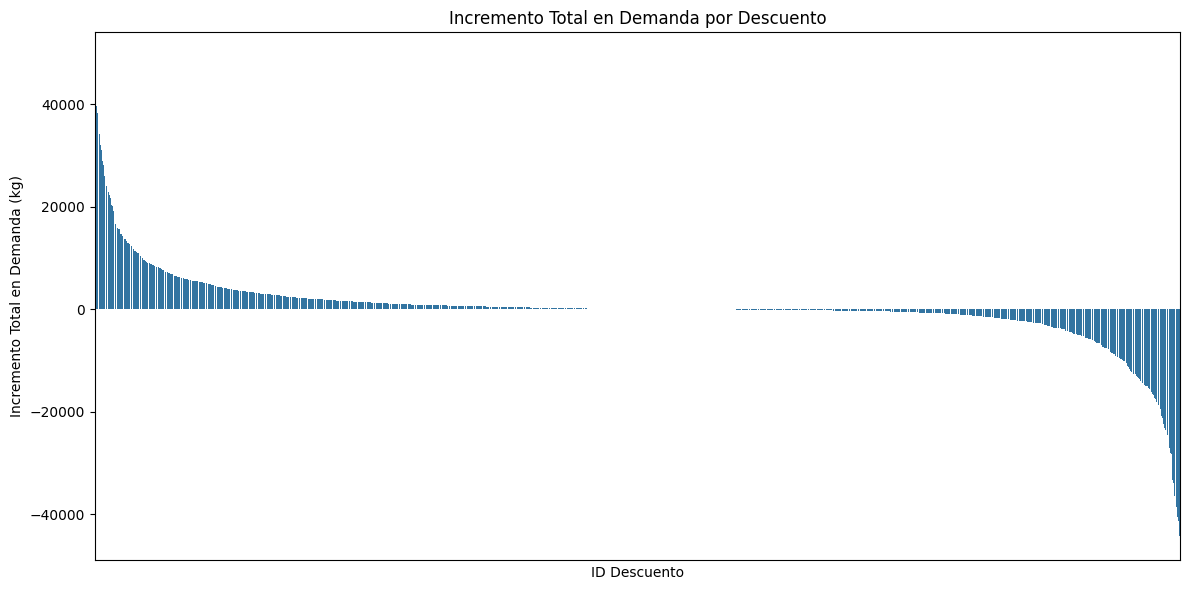

In [30]:
# Graficamos el incremento de demanda de cada descuento, ordenados de mayor a menor en el eje x del gráfico
data_grafico = resultados_df.sort_values("Incremento Demanda Total (kg)", ascending=False)

# tratar id como string para que se grafique bien
data_grafico["id_descuento"] = data_grafico["id_descuento"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=data_grafico, x="id_descuento", y="Incremento Demanda Total (kg)", )
plt.title("Incremento Total en Demanda por Descuento")
plt.xlabel("ID Descuento")
plt.ylabel("Incremento Total en Demanda (kg)")
plt.xticks([])
plt.tight_layout()
plt.show()

filtrar con los que el periodo duró 3 meses o menos.

## 4.2 Descuentos ordenados por ROP

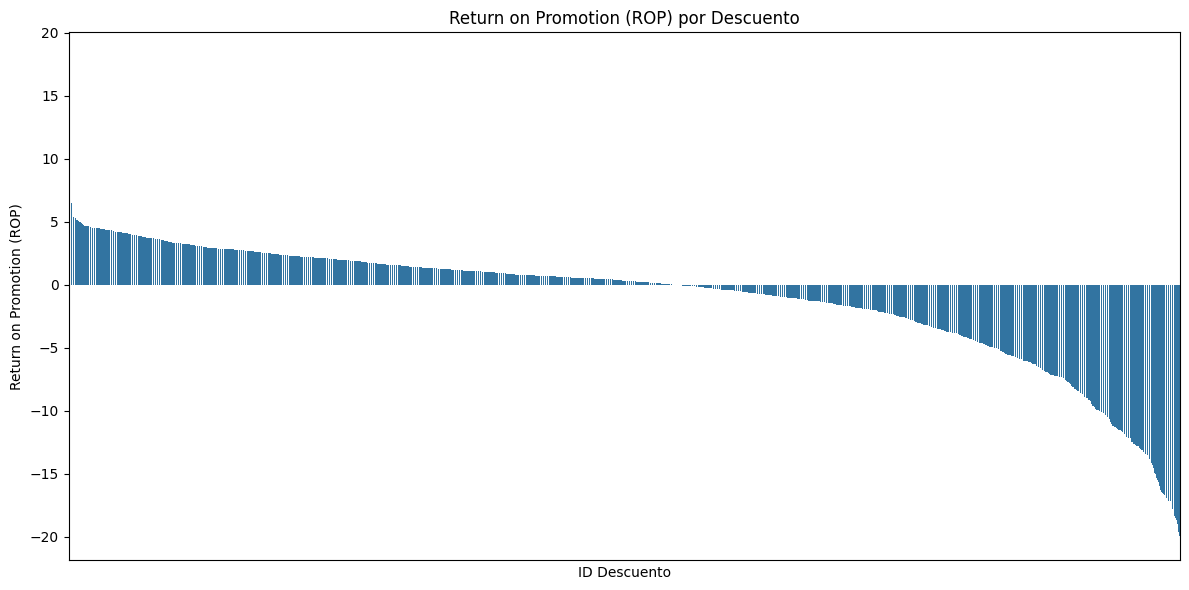

In [31]:
# Graficamos el ROP de cada descuento, ordenados de mayor a menor
data_grafico = resultados_df.sort_values("ROP", ascending=False)

# tratar id como string para que se grafique bien
data_grafico["id_descuento"] = data_grafico["id_descuento"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=data_grafico, x="id_descuento", y="ROP")
plt.title("Return on Promotion (ROP) por Descuento")
plt.xlabel("ID Descuento")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.tight_layout()
plt.show()

In [32]:
resultados_df.to_csv("resultados_retornos.csv", index=False)

In [33]:
type(baseline_cache)

dict

In [34]:
from pathlib import Path
import pickle

output_path = Path("baseline_cache.pkl")
with output_path.open("wb") as f:
    pickle.dump(baseline_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

output_path.resolve()

PosixPath('/Users/summa/Documents/GitHub/ci0103/baseline_cache.pkl')